# Hours and Scores dataset
### Linear Regression

Hours and Scores dataset in this project uses Linear Regression to predict student scores based on study hours. It helps understand how the number of 
hours studied affects exam performance.
 (As we know that education plays an important role in student performance. This project analyzes the reationship between study hours and exam scores using Linear regression, this model predicts student marks based on the number of hous studied.)

#### Why this project?
I started with a simple dataset to understand the basic concept of Linear Regression and how input variables affect output prediction.

#### In this dataset has only three columns

##### 1.without any name
###### 2.Hours - Number of hours studied
###### 3.Scores - Marks obtained by students

In [34]:
# importing libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
%matplotlib inline

In [4]:
# load dataset
# import csv in this project
df=pd.read_csv("Hours and Scores.csv")

### Basic Checks

In [5]:
df.head()

,Unnamed: 0,Hours,Scores
0,"2.5,21",2.5,21
1,"5.1,47",5.1,47
2,"3.2,27",3.2,27
3,"8.5,75",8.5,75
4,"3.5,30",3.5,30


In [6]:
df.tail()

,Unnamed: 0,Hours,Scores
20,"2.7,30",2.7,30
21,"4.8,54",4.8,54
22,"3.8,35",3.8,35
23,"6.9,76",6.9,76
24,"7.8,86",7.8,86


In [7]:
df.shape

(25, 3)

In [10]:
df.columns

Index(['Unnamed: 0', 'Hours', 'Scores'], dtype='object')

In [12]:
df.describe()

,Hours,Scores
count,25.000000,25.000000
mean,5.012000,51.480000
std,2.525094,25.286887
min,1.100000,17.000000
25%,2.700000,30.000000
50%,4.800000,47.000000
75%,7.400000,75.000000
max,9.200000,95.000000


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  25 non-null     object 
 1   Hours       25 non-null     float64
 2   Scores      25 non-null     int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 732.0+ bytes


In [14]:
df.isnull()

,Unnamed: 0,Hours,Scores
0,False,False,False
1,False,False,False
2,False,False,False
3,False,False,False
4,False,False,False
5,False,False,False
6,False,False,False
7,False,False,False
8,False,False,False
9,False,False,False


### EDA (Exploratory Data Analysis)

In EDA, I checked data structure, handled missing values, performed statistical analysis, visualized the relationship using scatter plots, and 
checked correlation between study hours and scores.

In [18]:
df

,Unnamed: 0,Hours,Scores
0,"2.5,21",2.5,21
1,"5.1,47",5.1,47
2,"3.2,27",3.2,27
3,"8.5,75",8.5,75
4,"3.5,30",3.5,30
5,"1.5,20",1.5,20
6,"9.2,88",9.2,88
7,"5.5,60",5.5,60
8,"8.3,81",8.3,81
9,"2.7,25",2.7,25


In [16]:
df.isnull().sum()

Unnamed: 0    0
Hours         0
Scores        0
dtype: int64

In [ ]:
#Univariate Analysis:-
we do univarient analysis to understand the data (what value present, is it small or large), Check distribution (is data normal-balanced, or data is 
skewed-more on one side), Check outliers- any unusual or extreme data, Check data quality- missing values, wrong values, get summary statistics-mean,
median,min,max


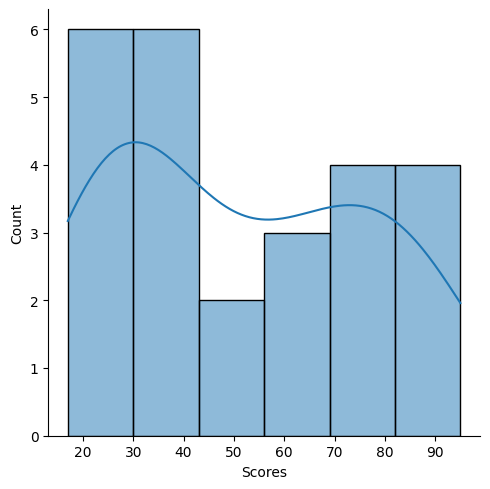

In [7]:
#Step 1 Univariate Analysis
sns.displot(x=df.Scores,kde=True)

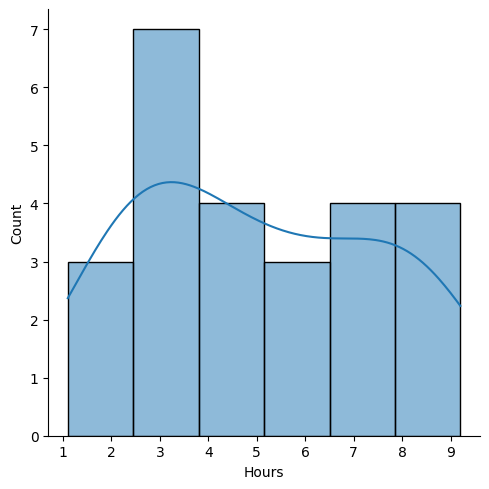

In [8]:
sns.displot(x=df.Hours,kde=True)

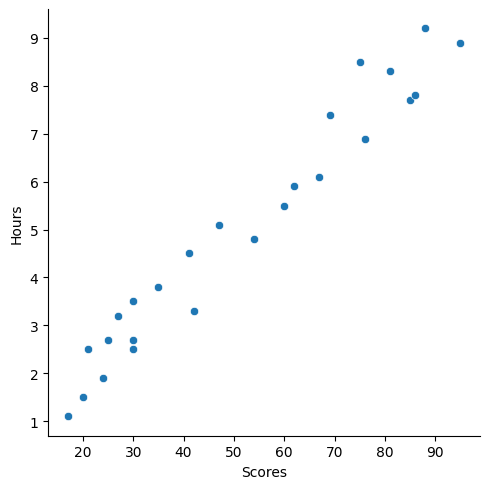

In [12]:
sns.relplot(x='Scores', y='Hours', data=df)

In [8]:
#Histogram :- How data is spread -> Normal or skewed

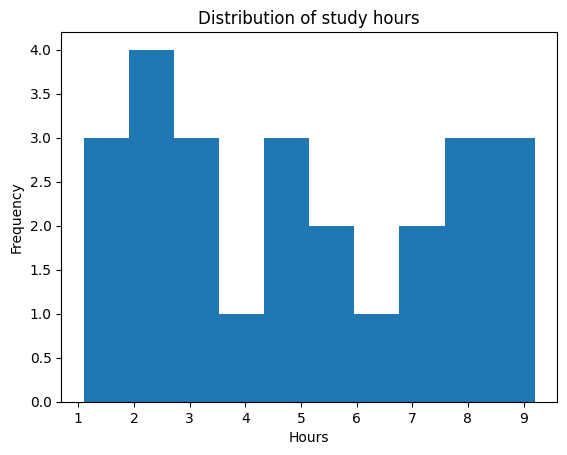

In [9]:
# Histogram distribution by label
plt.hist(df["Hours"])
plt.title("Distribution of study hours")
plt.xlabel("Hours")
plt.ylabel("Frequency")
plt.show()

In [9]:
# Boxplot :- Outliers (extreme values) ,Median (middle value)

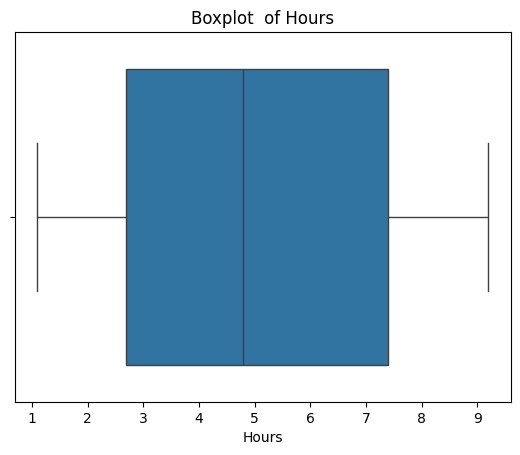

In [6]:
# Boxplot (Outlier Check)
sns.boxplot(x=df["Hours"])
plt.title("Boxplot  of Hours")
plt.show()

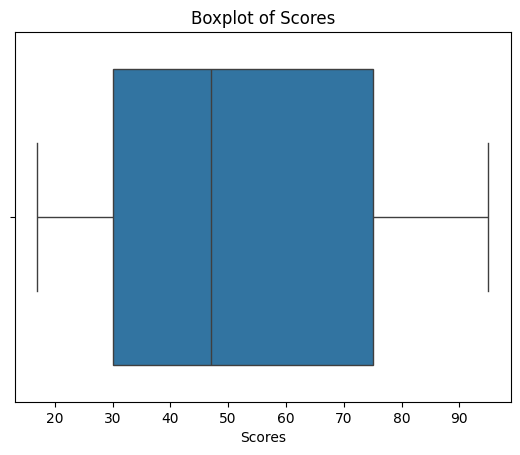

In [7]:
sns.boxplot(x=df["Scores"])
plt.title("Boxplot of Scores")
plt.show()

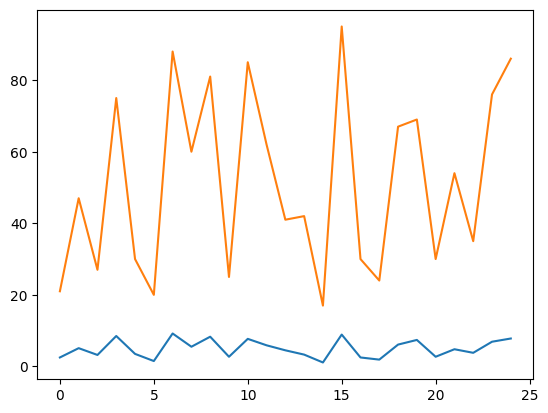

In [15]:
plt.plot(df.Hours)
plt.plot(df.Scores)

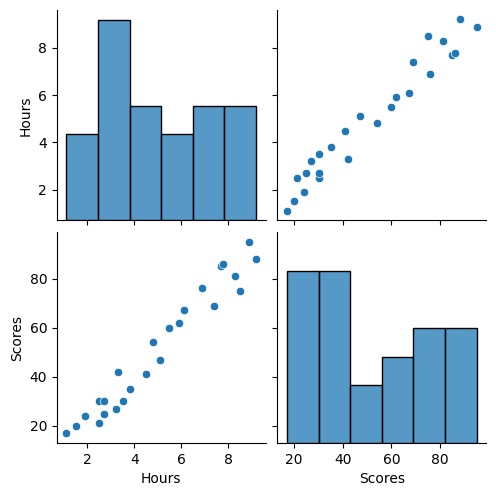

In [17]:
sns.pairplot(df)

### Data preprocessing and feature engineerinng

In [18]:
#step.1 :- finding missing values
df.isnull().sum()

Unnamed: 0    0
Hours         0
Scores        0
dtype: int64

In [ ]:
#step.2 :- Converting categorical data to numerical


<Axes: xlabel='Scores'>

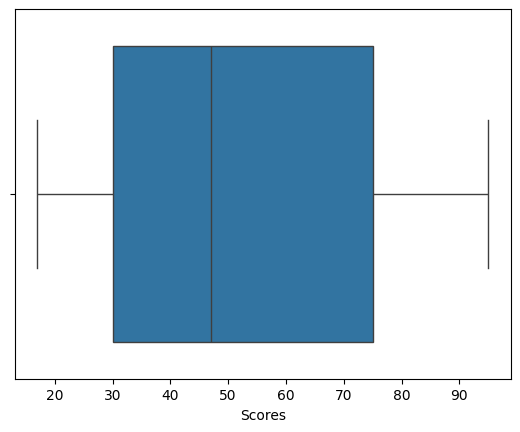

In [19]:
# Step 3 Checking the outlier

sns.boxplot(x='Scores',data=df) #more than 3 sigma-outliers

In [ ]:
# Step 4 Scaling the continous variable


In [ ]:
# Step 5 Transformation


In [ ]:
# Step 6 Balacing the data


### Feature Selection

In [ ]:
#step.1- remove unwanted variable/column
l1=['Unnamed: 0']
df.drop(l1,axis=1,inplace=True)

In [24]:
df

,Hours,Scores
0,2.5,21
1,5.1,47
2,3.2,27
3,8.5,75
4,3.5,30
5,1.5,20
6,9.2,88
7,5.5,60
8,8.3,81
9,2.7,25


<Axes: >

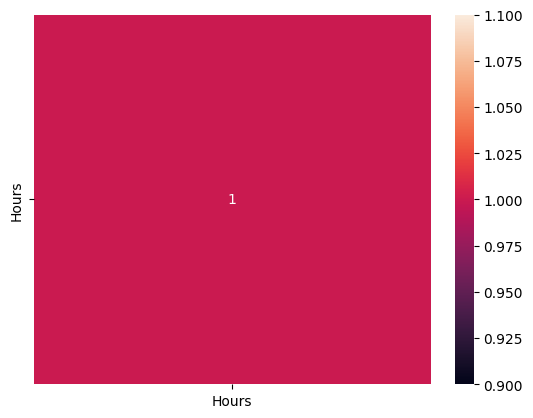

In [27]:
## Step 2 Checking the correlation
sns.heatmap(df.drop('Scores',axis=1).corr(),annot=True)

In [29]:
df.corr()

,Hours,Scores
Hours,1.000000,0.976191
Scores,0.976191,1.000000


### Model creation

In [30]:
df.head()

,Hours,Scores
0,2.5,21
1,5.1,47
2,3.2,27
3,8.5,75
4,3.5,30


In [31]:
# Step.1:- independent and dependent variable creation
X=df[['Hours']] ## X variable contains all inputs
y=df.Scores ## y is output

In [32]:
X

,Hours
0,2.5
1,5.1
2,3.2
3,8.5
4,3.5
5,1.5
6,9.2
7,5.5
8,8.3
9,2.7


In [33]:
y

0     21
1     47
2     27
3     75
4     30
5     20
6     88
7     60
8     81
9     25
10    85
11    62
12    41
13    42
14    17
15    95
16    30
17    24
18    67
19    69
20    30
21    54
22    35
23    76
24    86
Name: Scores, dtype: int64

In [36]:
# step.2 :- training and testing data creation
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=4)

In [37]:
y_train

10    85
6     88
11    62
2     27
4     30
19    69
17    24
15    95
16    30
24    86
13    42
7     60
9     25
18    67
20    30
8     81
1     47
5     20
23    76
14    17
Name: Scores, dtype: int64

In [38]:
y_test

22    35
21    54
0     21
3     75
12    41
Name: Scores, dtype: int64

In [39]:
X_train

,Hours
10,7.7
6,9.2
11,5.9
2,3.2
4,3.5
19,7.4
17,1.9
15,8.9
16,2.5
24,7.8


In [40]:
X_test

,Hours
22,3.8
21,4.8
0,2.5
3,8.5
12,4.5


In [41]:
#step.3:- creating model
from sklearn.linear_model import LinearRegression
LR=LinearRegression() #object creation
LR.fit(X_train,y_train) #training of linear regression
y_predict=LR.predict(X_test)

In [43]:
y_test # actual value

22    35
21    54
0     21
3     75
12    41
Name: Scores, dtype: int64

In [44]:
y_predict # Values predicted by model

array([40.60416792, 50.48181243, 27.76323006, 87.0290971 , 47.51851908])

In [46]:
#step.4 :- Model Evaluation

from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
r2score=r2_score(y_test,y_predict)

In [48]:
r2score

0.8345792140066827

In [49]:
X_test.shape

(5, 1)

In [52]:
# calculation of adjusted r2 score
adjusted_r2=1-(1-0.90)*(40-1)/(40-3-1)
adjusted_r2

0.8916666666666667

In [53]:
import math
print(mean_squared_error(y_test,y_predict))
print(math.sqrt(mean_squared_error(y_test,y_predict))) # root mean squared error

55.34317816192426
7.439299574686064


In [54]:
print(mean_absolute_error(y_test,y_predict))

6.886640347176178
